# Feature Analysis

**Goal:** Characterise individual predictors in relation to the 9 binary clinical endpoints.
This notebook complements the PCA analysis (which operates on the full feature space) with
univariate and pairwise analyses that are easier to interpret clinically.

**Sections:**
1. Imports & data loading
2. Continuous feature distributions by outcome (violin plots)
3. Binary feature prevalence by outcome (bar charts)
4. Univariate logistic regression – odds ratios & forest plot
5. Mutual information between features and targets
6. Binary feature co-occurrence (Cramér's V heatmap among predictors)

## 1. Imports & Data Loading

In [1]:
import os
import sys
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

print(f'Features: {X.shape[0]:,} patients × {X.shape[1]} predictors')
print(f'Targets:  {y.shape[0]:,} patients × {y.shape[1]} endpoints')

CONTINUOUS_FEATURES = [
    'pci_tropo_pre', 'ic_age_mon', 'pci_platel_pre', 'fup_nyha', 'lvef',
    'heartrate', 'pci_glycemia', 'prec_hb', 'pci_creatinine_pre', 'prec_wbc',
    'bmi', 'pci_platelvol_pre', 'prior_mi', 'bp_sys', 'contrast',
    'pci_platelvol_ldis', 'prior_pci', 'prec_creatinine', 'pci_tropo_ldis',
    'height', 'fup_ccs'
]

# Drop features removed by the cleaning pipeline (e.g. >40% missing) so this
# notebook stays in sync with the current X_features.parquet schema.
CONTINUOUS_FEATURES = [c for c in CONTINUOUS_FEATURES if c in X.columns]

# Exploratory full-cohort median imputation of the (now un-imputed) numeric
# features. There is no train/test split in this descriptive notebook, so
# this is not leakage; predictive pipelines impute inside CV instead.
X[CONTINUOUS_FEATURES] = X[CONTINUOUS_FEATURES].fillna(X[CONTINUOUS_FEATURES].median())


BINARY_FEATURES = [c for c in X.columns
                   if c not in CONTINUOUS_FEATURES and c != 'regimen']

TARGET_LABELS = {
    'cec_bleed_335d':   'Any Bleeding',
    'cec_barc235_335d': 'BARC 2-3-5',
    'cec_revasc_335d':  'Revascularization',
    'cec_mi_335d':      'MI',
    'cec_cvdeath_335d': 'CV Death',
    'cec_stroke_335d':  'Stroke',
    'cec_barc2_335d':   'BARC 2',
    'cec_barc3_335d':   'BARC 3',
    'cec_barc35_335d':  'BARC 3-5',
}

# Focus targets for detailed plots (most prevalent and clinically distinct)
FOCUS_TARGETS = {
    'cec_bleed_335d':   'Any Bleeding (11.1%)',
    'cec_barc235_335d': 'BARC 2-3-5 (7.8%)',
    'cec_revasc_335d':  'Revascularization (3.5%)',
    'cec_cvdeath_335d': 'CV Death (1.8%)',
}

Features: 4,579 patients × 61 predictors
Targets:  4,579 patients × 9 endpoints


In [3]:
SHORT_NAMES = {
    # Continuous
    'pci_tropo_pre':        'Troponin pre',
    'pci_tropo_ldis':       'Troponin post',
    'ic_age_mon':           'Age (months)',
    'pci_platel_pre':       'Platelets pre',
    'fup_nyha':             'NYHA class',
    'lvef':                 'LVEF (%)',
    'heartrate':            'Heart rate',
    'pci_glycemia':         'Glycemia',
    'prec_hb':              'Haemoglobin',
    'pci_creatinine_pre':   'Creatinine pre',
    'prec_wbc':             'WBC',
    'bmi':                  'BMI',
    'pci_platelvol_pre':    'Plt volume pre',
    'prior_mi':             'Prior MI (count)',
    'bp_sys':               'Systolic BP',
    'contrast':             'Contrast vol',
    'pci_platelvol_ldis':   'Plt volume post',
    'prior_pci':            'Prior PCI (count)',
    'prec_creatinine':      'Creatinine base',
    'height':               'Height (cm)',
    'fup_ccs':              'CCS class',
    # Binary — original flags
    'fup_other':            'Other FU event',
    'rand_oac12':           'OAC at random.',
    'cancer':               'Cancer',
    'prec_priorbleed':      'Prior bleed (PRECISE)',
    'p_bleed':              'Prior bleed',
    'rand_ster_nsaid':      'Steroid/NSAID',
    'rand_anemia':          'Anemia',
    'fup_nitrates':         'Nitrates (FU)',
    'fup_insulin':          'Insulin (FU)',
    'prior_cabg':           'Prior CABG',
    'prior_mi_12m':         'Prior MI <12m',
    'cad':                  'CAD',
    'hyperlipidemia':       'Hyperlipidemia',
    'gender_encoded':       'Male sex',
    # acs_last_pci one-hot
    'acs_last_pci_ACS STEMI':           'STEMI (last PCI)',
    'acs_last_pci_ACS NSTEMI':          'NSTEMI (last PCI)',
    'acs_last_pci_Stable angina':       'Stable angina (last PCI)',
    'acs_last_pci_ACS Unstable angina': 'Unstable angina (last PCI)',
    'acs_last_pci_Silent Ischemia':     'Silent ischemia (last PCI)',
    'acs_last_pci_Staged procedure':    'Staged proc. (last PCI)',
    # acs one-hot
    'acs_ACS STEMI':           'ACS STEMI',
    'acs_ACS NSTEMI':          'ACS NSTEMI',
    'acs_Stable angina':       'ACS stable angina',
    'acs_ACS Unstable angina': 'ACS unstable angina',
    'acs_Silent Ischemia':     'ACS silent ischemia',
    # diabetes one-hot
    'diabetes_no':                              'No DM',
    'diabetes_type II oral drugs':              'DM II oral',
    'diabetes_type II insulin and oral drugs':  'DM II insulin+oral',
    'diabetes_type II insulin':                 'DM II insulin',
    'diabetes_type II diet':                    'DM II diet',
    'diabetes_type I-insulin dependent':        'DM I insulin',
    # afib one-hot
    'afib_no':                              'No AFib',
    'afib_yes - paroxysmal':               'AFib parox.',
    'afib_yes - permanent':                'AFib permanent',
    'afib_yes - persistent':               'AFib persistent',
    'afib_yes - long-standing persistent': 'AFib long-standing',
    # smoker one-hot
    'smoker_no - never smoked':      'Non-smoker',
    'smoker_yes - previous smoker':  'Ex-smoker',
    'smoker_yes - current smoker':   'Current smoker',
    # alcohol one-hot
    'alcohol_never':                                              'No alcohol',
    'alcohol_yes - less than eight beers or equivalent per week': 'Alcohol <8 beers/wk',
    'alcohol_yes - eight beers and equivalent per week or more':  'Alcohol ≥8 beers/wk',
    'alcohol_yes - unknown consumption per week':                 'Alcohol (unknown qty)',
    'alcohol_unknown - the patient does not want to answer':      'Alcohol (refused)',
    # geography one-hot
    'geography_Europe':              'Europe',
    'geography_Asia':                'Asia',
    'geography_Australia/Argentina': 'Aus/Argentina',
    # race one-hot
    'race_Caucasian origin':         'Caucasian',
    'race_Asian origin':             'Asian',
    'race_Race is not collected':    'Race N/A',
    'race_African origin':           'African',
    'race_African American origin':  'African-American',
    'race_Native American origin':   'Native American',
    # p_bleed_action1 one-hot
    'p_bleed_action1___none__': 'No bleed action',
    'p_bleed_action1_Recent (<12 months) non access site bleeding event which required medical attention (ex. actionable bleeding)':
        'Recent bleed (<12m)',
    'p_bleed_action1_Previous bleeding episode  which required  hospitalization and the underlying cause has not been definitely treated':
        'Prior bleed (hosp.)',
    # proir_avs_yn one-hot
    'proir_avs_yn_yes': 'Prior AVS',
    'proir_avs_yn_no':  'No prior AVS',
}

def shorten(name, max_len=30):
    if name in SHORT_NAMES:
        return SHORT_NAMES[name]
    s = (name
         .replace('yes - ', '').replace('no - ', '')
         .replace('_yes', ' yes').replace('_no', ' no'))
    return s if len(s) <= max_len else s[:max_len - 2] + '..'

## 2. Continuous Feature Distributions by Outcome

For each of the 4 focus targets, violin plots show how the distribution of each
continuous clinical variable differs between patients who experienced the event
(Event = 1) and those who did not (Event = 0).

A Mann-Whitney U p-value is annotated above each violin pair; asterisks follow the
convention * p<0.05, ** p<0.01, *** p<0.001.

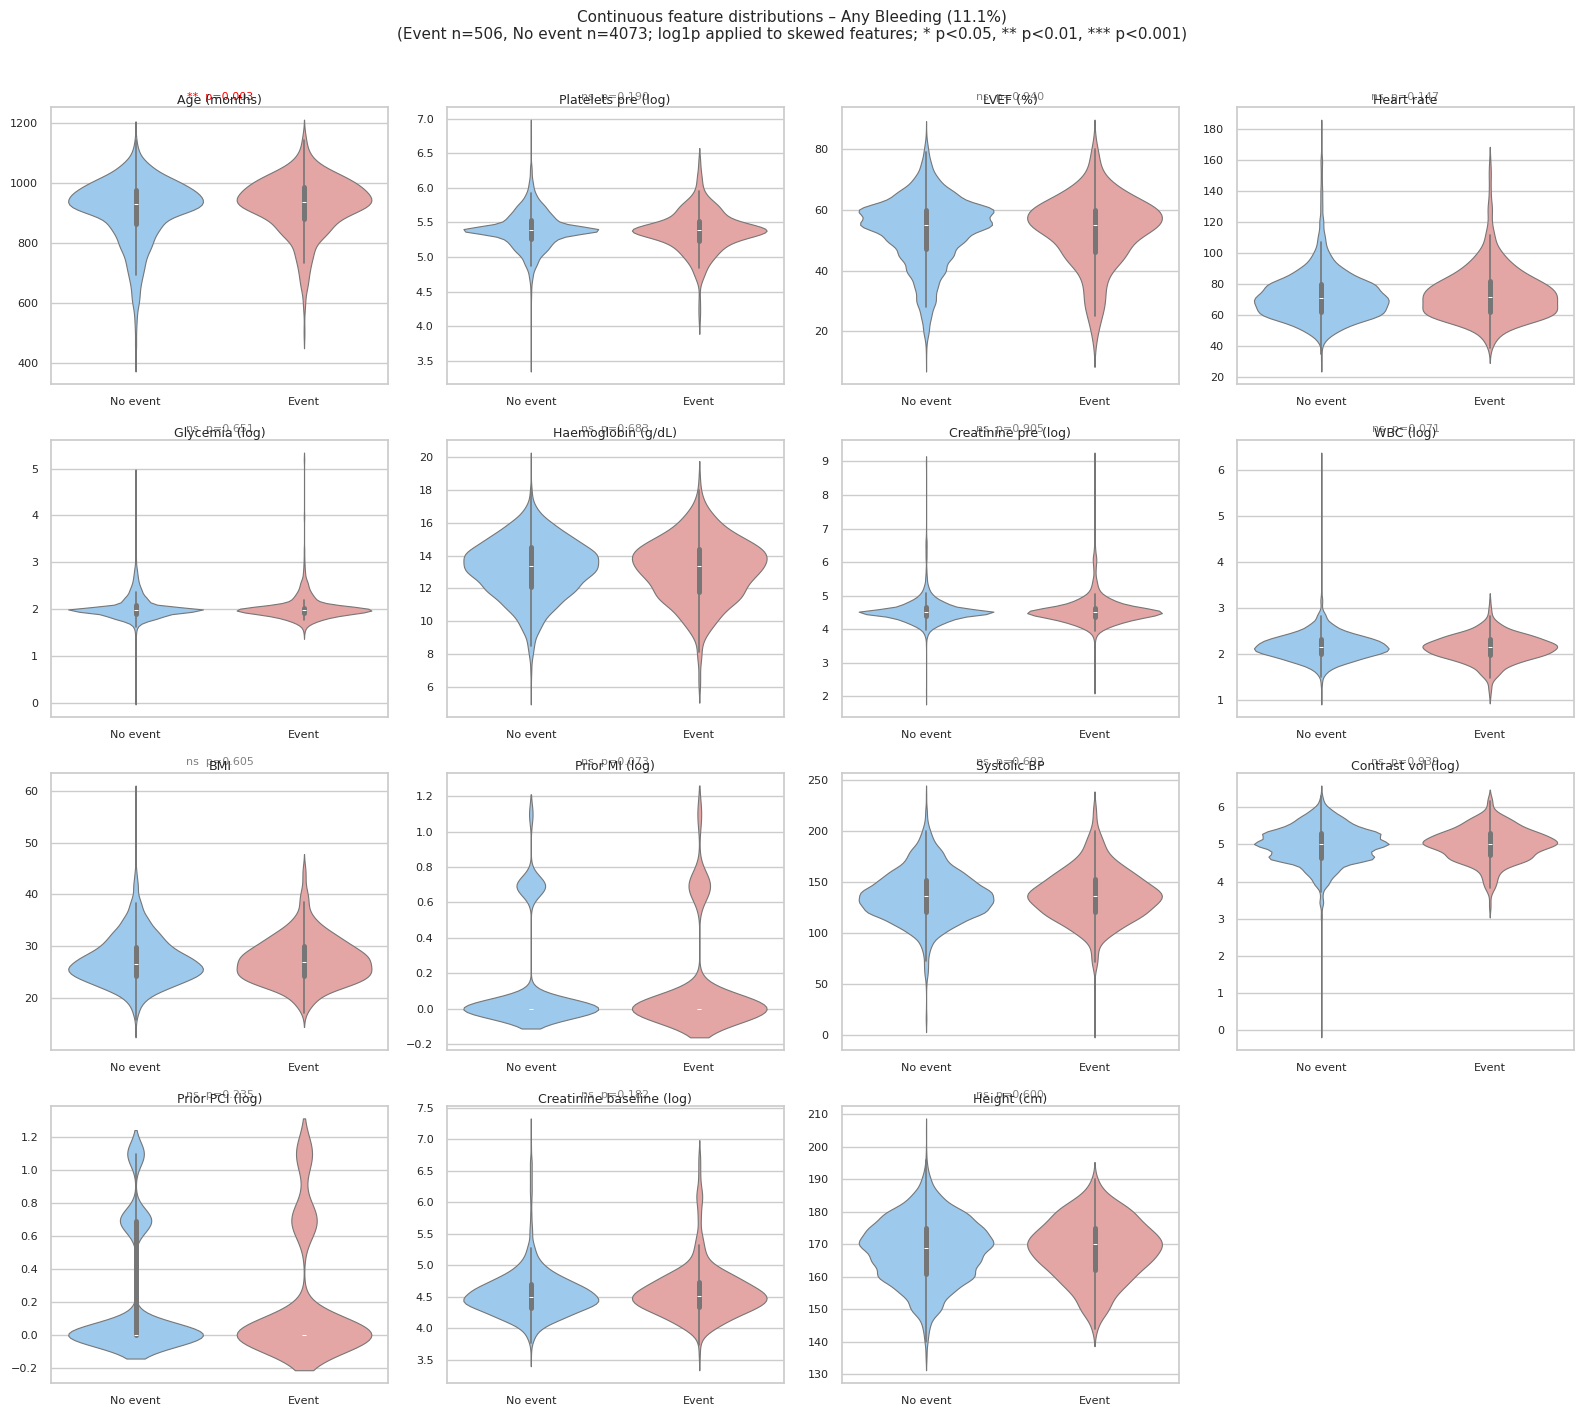

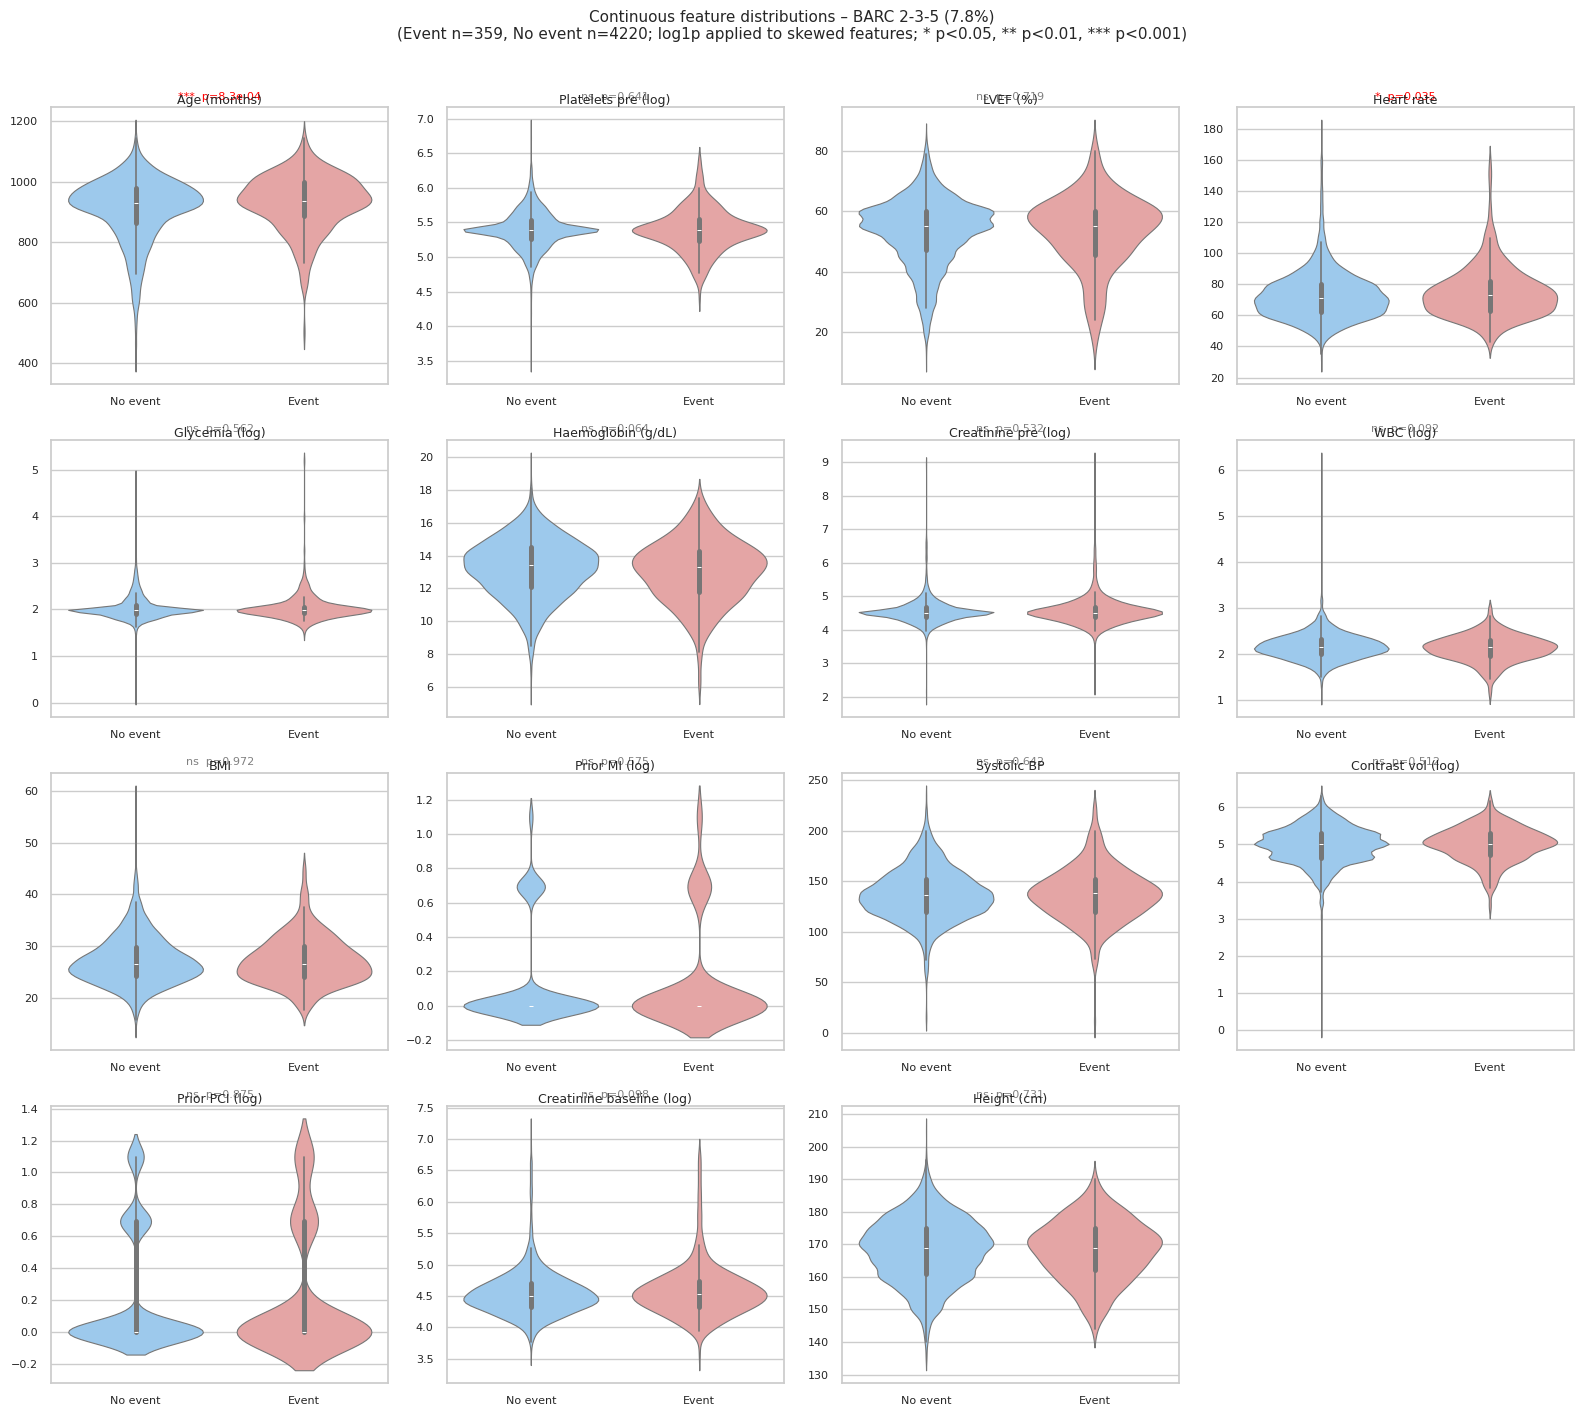

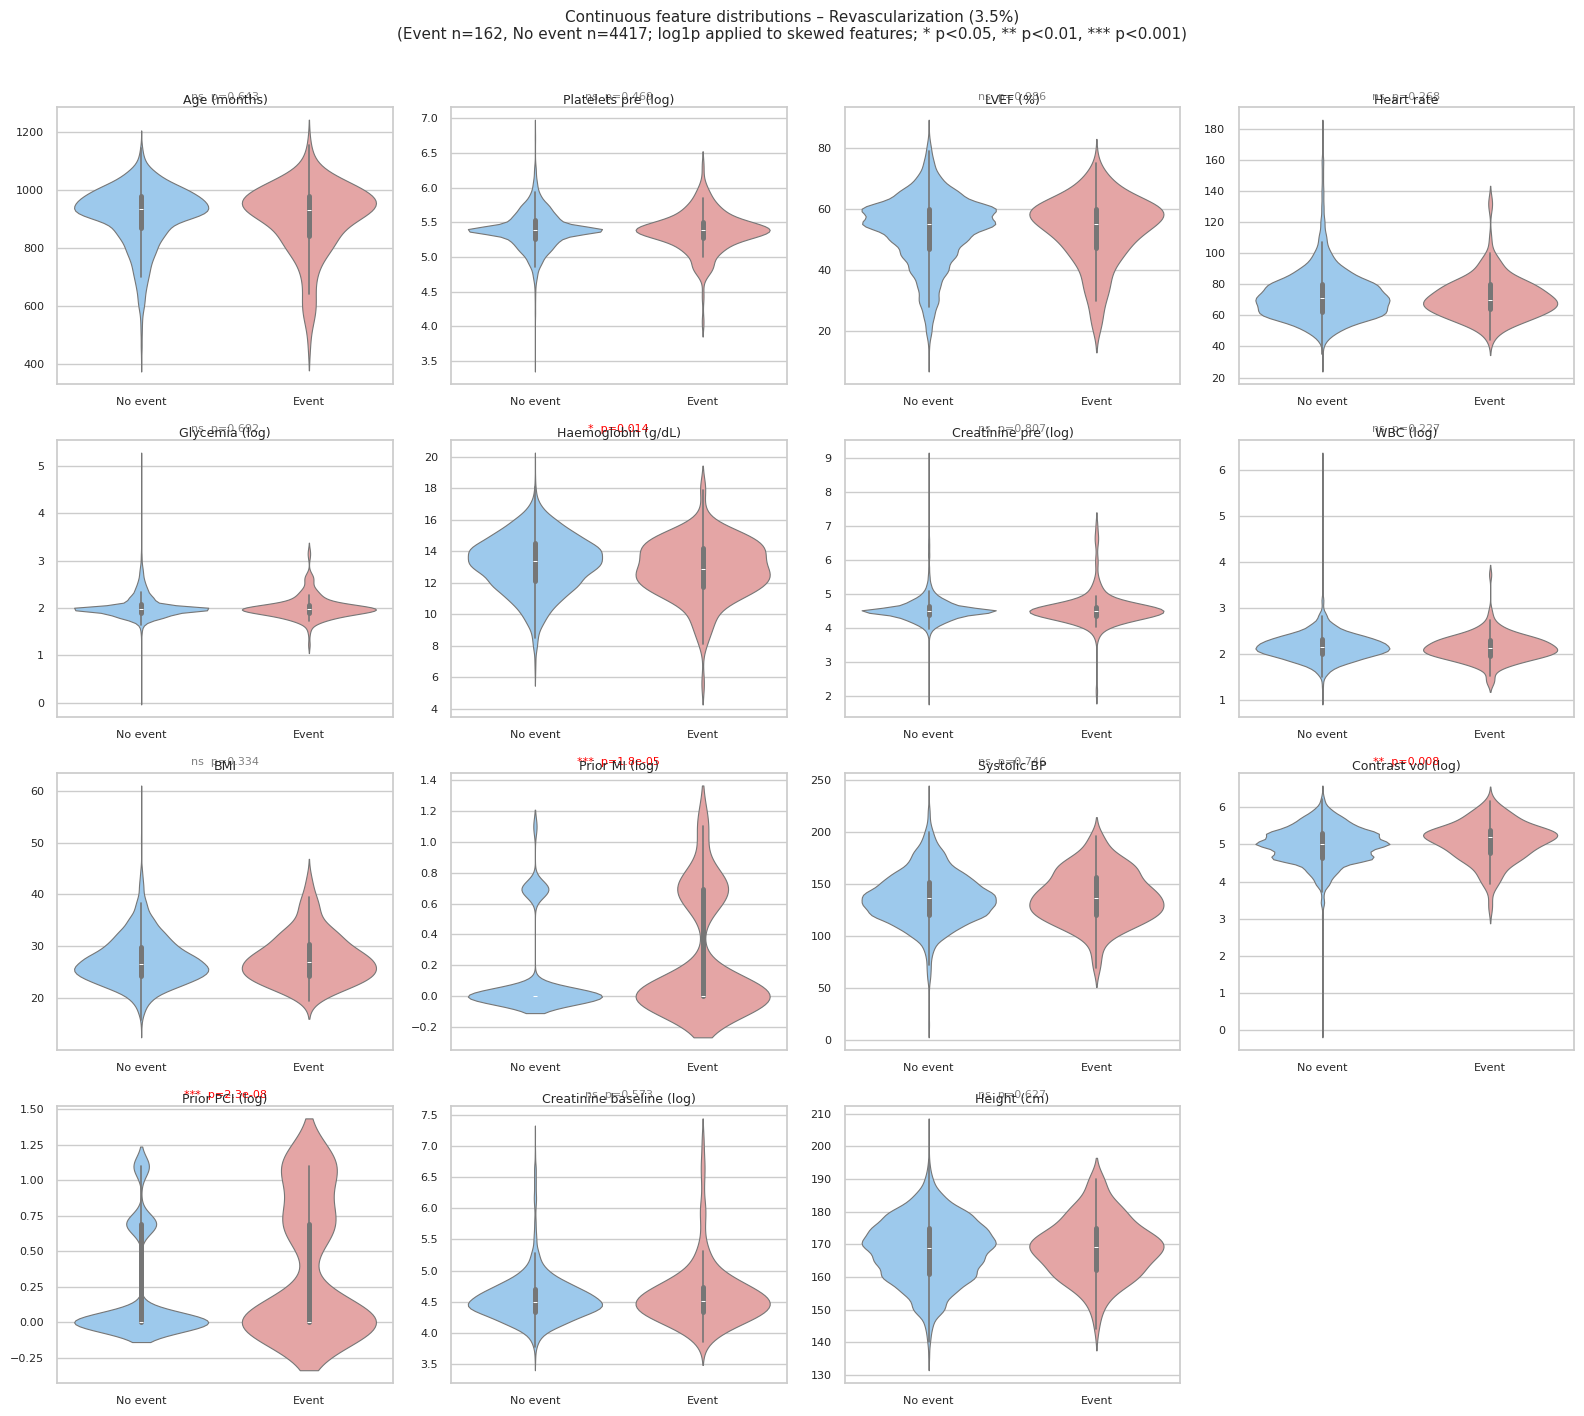

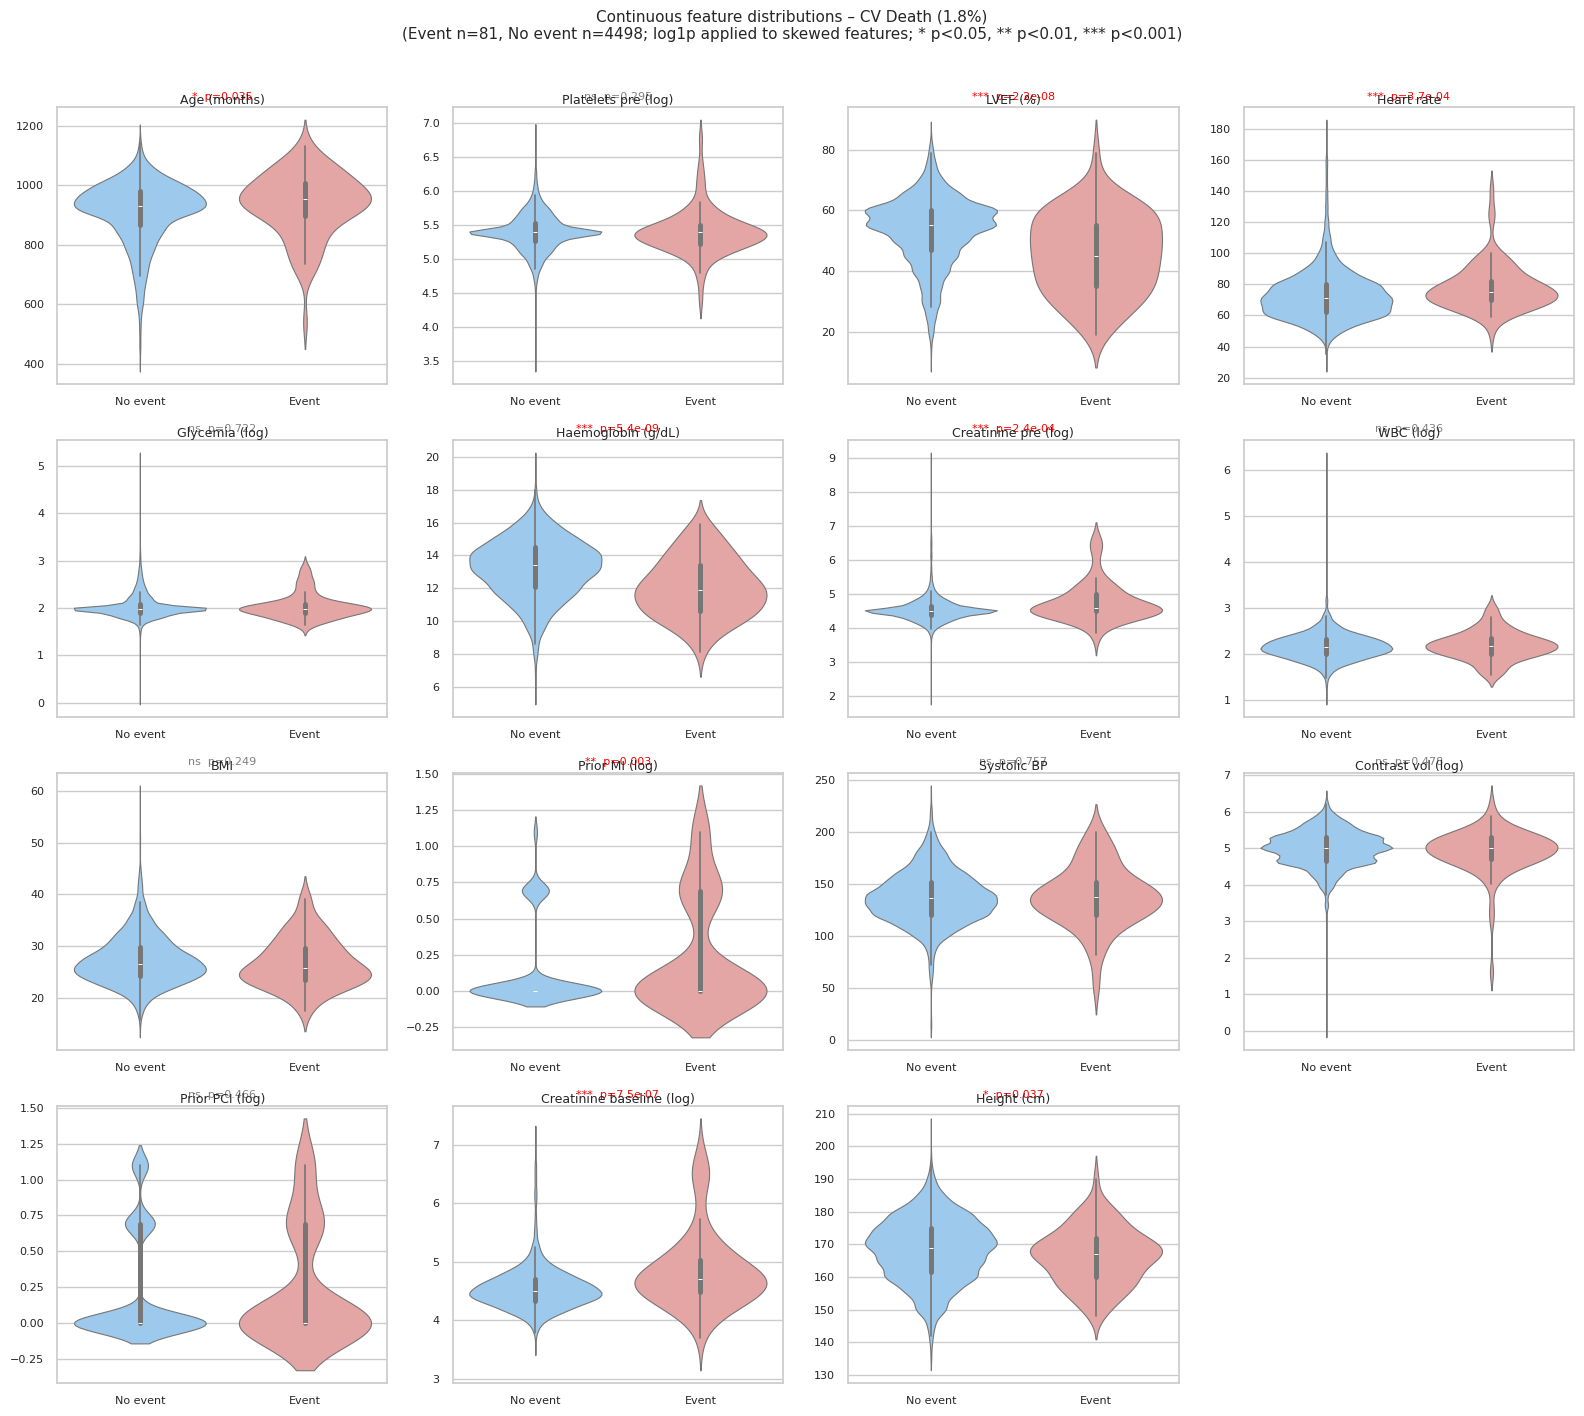

In [4]:
import math

SKEWED = [
    'pci_tropo_pre', 'pci_tropo_ldis', 'pci_creatinine_pre', 'prec_creatinine',
    'prec_wbc', 'pci_platelvol_pre', 'pci_platelvol_ldis', 'pci_glycemia',
    'contrast', 'fup_ccs', 'pci_platel_pre', 'prior_mi', 'prior_pci', 'fup_nyha'
]
SKEWED = [c for c in SKEWED if c in X.columns]

# Log1p-transform skewed features for display
X_disp = X[CONTINUOUS_FEATURES].astype(float).copy()
X_disp[SKEWED] = np.log1p(X_disp[SKEWED])

FEAT_LABELS = {
    'pci_tropo_pre': 'Troponin pre (log)',
    'pci_tropo_ldis': 'Troponin post (log)',
    'ic_age_mon': 'Age (months)',
    'pci_platel_pre': 'Platelets pre (log)',
    'fup_nyha': 'NYHA class (log)',
    'lvef': 'LVEF (%)',
    'heartrate': 'Heart rate',
    'pci_glycemia': 'Glycemia (log)',
    'prec_hb': 'Haemoglobin (g/dL)',
    'pci_creatinine_pre': 'Creatinine pre (log)',
    'prec_wbc': 'WBC (log)',
    'bmi': 'BMI',
    'pci_platelvol_pre': 'Platelet vol pre (log)',
    'prior_mi': 'Prior MI (log)',
    'bp_sys': 'Systolic BP',
    'contrast': 'Contrast vol (log)',
    'pci_platelvol_ldis': 'Platelet vol post (log)',
    'prior_pci': 'Prior PCI (log)',
    'prec_creatinine': 'Creatinine baseline (log)',
    'height': 'Height (cm)',
    'fup_ccs': 'CCS class (log)',
}

def mw_stars(g0, g1):
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')
    if p < 0.001: return '***', p
    if p < 0.01:  return '**',  p
    if p < 0.05:  return '*',   p
    return 'ns', p

for target_col, target_lbl in FOCUS_TARGETS.items():
    y_col = y[target_col].astype(int).values
    n_event = y_col.sum()

    ncols = 4
    nrows = math.ceil(len(CONTINUOUS_FEATURES) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
    axes = axes.flatten()

    for i, feat in enumerate(CONTINUOUS_FEATURES):
        ax = axes[i]
        g0 = X_disp.loc[y_col == 0, feat].dropna()
        g1 = X_disp.loc[y_col == 1, feat].dropna()

        plot_df = pd.DataFrame({
            'value': pd.concat([g0, g1]),
            'group': ['No event'] * len(g0) + ['Event'] * len(g1)
        })

        sns.violinplot(
            data=plot_df, x='group', y='value',
            order=['No event', 'Event'],
            palette=['#90CAF9', '#EF9A9A'],
            inner='box', linewidth=0.8, ax=ax
        )

        stars, p = mw_stars(g0, g1)
        color = 'red' if p < 0.05 else 'gray'
        ymax = plot_df['value'].max()
        ax.text(0.5, 1.02, f'{stars}  p={p:.3f}' if p >= 0.001 else f'{stars}  p={p:.1e}',
                transform=ax.transAxes, ha='center', va='bottom',
                fontsize=8, color=color)

        ax.set_title(FEAT_LABELS.get(feat, feat), fontsize=9, pad=2)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(labelsize=8)

    for j in range(len(CONTINUOUS_FEATURES), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f'Continuous feature distributions – {target_lbl}\n'
        f'(Event n={n_event}, No event n={len(y_col)-n_event}; '
        f'log1p applied to skewed features; * p<0.05, ** p<0.01, *** p<0.001)',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()

## 3. Binary Feature Prevalence by Outcome

For each focus target, we compute the prevalence (% with feature = 1) separately in
the event and no-event group, and show only features where the difference is
statistically significant (chi-square p < 0.05).

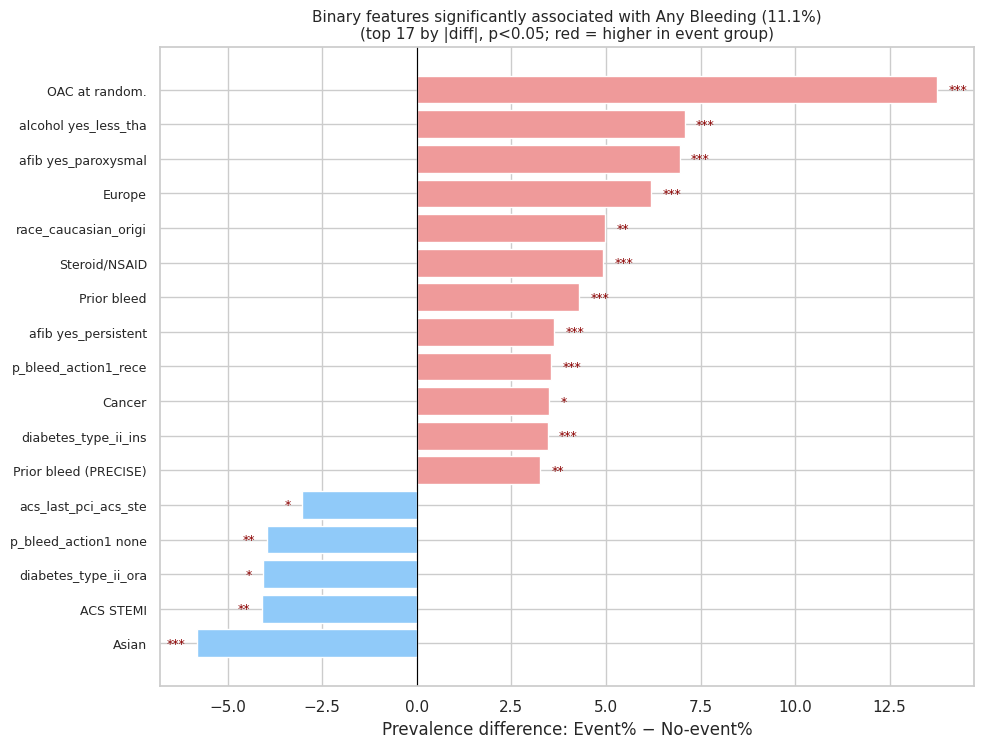

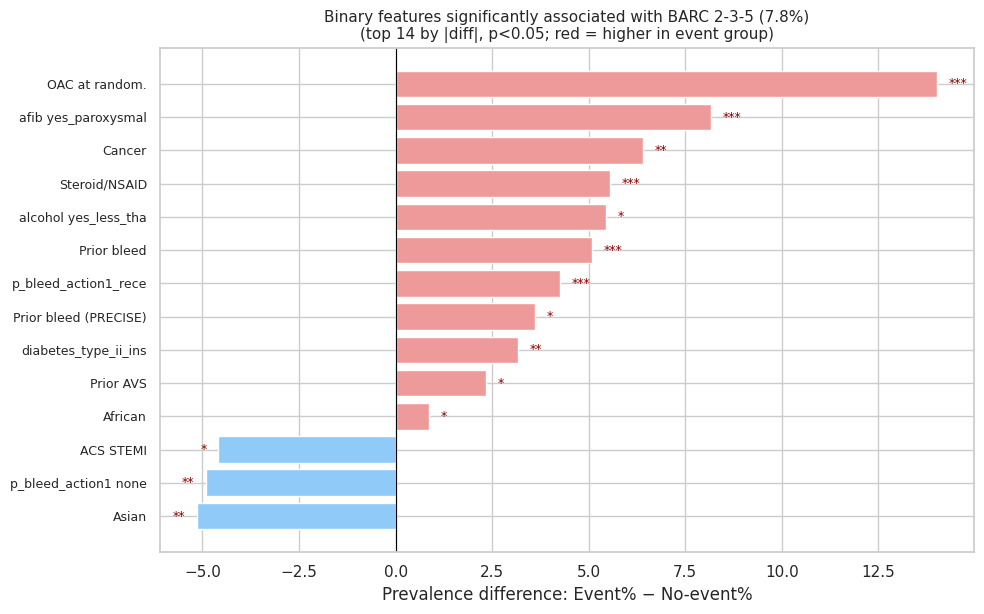

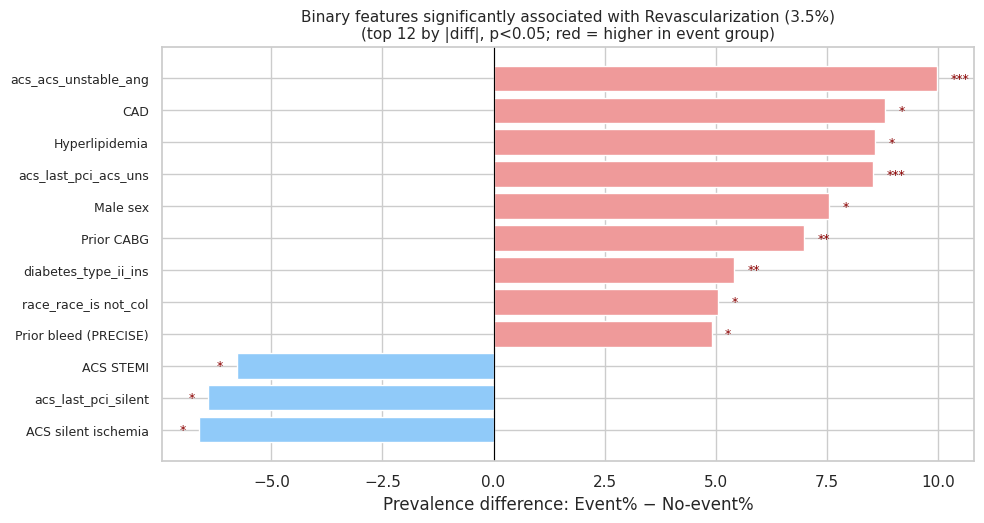

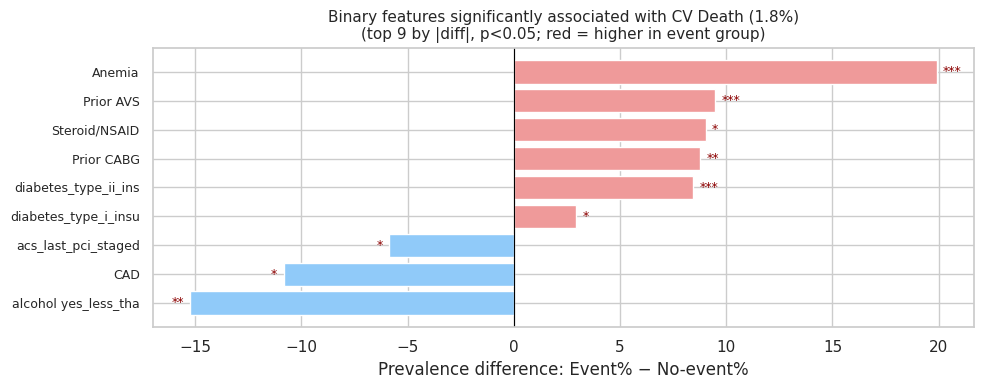

In [5]:
for target_col, target_lbl in FOCUS_TARGETS.items():
    y_col = y[target_col].astype(int).values

    rows = []
    for feat in BINARY_FEATURES:
        f = X[feat].astype(int)
        ct = pd.crosstab(y_col, f)
        if ct.shape != (2, 2):
            continue
        chi2, p, _, _ = chi2_contingency(ct)
        prev_event    = f[y_col == 1].mean() * 100
        prev_no_event = f[y_col == 0].mean() * 100
        rows.append({
            'feature': feat,
            'event_%': prev_event,
            'no_event_%': prev_no_event,
            'diff': prev_event - prev_no_event,
            'p_value': p
        })

    res = (
        pd.DataFrame(rows)
        .query('p_value < 0.05')
        .sort_values('diff', key=abs, ascending=False)
        .head(20)
        .sort_values('diff')
    )

    if res.empty:
        print(f'{target_lbl}: no binary feature significant at p<0.05')
        continue

    labels = res['feature'].map(shorten).tolist()

    fig, ax = plt.subplots(figsize=(10, max(3, len(res) * 0.45)))
    colors = ['#EF9A9A' if d > 0 else '#90CAF9' for d in res['diff']]
    ax.barh(labels, res['diff'].values, color=colors)
    ax.axvline(0, color='black', lw=0.8)

    for lbl, (_, row) in zip(labels, res.iterrows()):
        stars = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*'
        xpos = row['diff'] + (0.3 if row['diff'] >= 0 else -0.3)
        ax.text(xpos, lbl, stars, va='center', ha='left' if row['diff'] >= 0 else 'right',
                fontsize=9, color='darkred')

    ax.set_xlabel('Prevalence difference: Event% − No-event%')
    ax.set_title(
        f'Binary features significantly associated with {target_lbl}\n'
        f'(top {len(res)} by |diff|, p<0.05; red = higher in event group)',
        fontsize=11
    )
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

## 4. Univariate Logistic Regression – Odds Ratios & Forest Plot

We fit a separate logistic regression for each (feature, target) pair to obtain the
odds ratio (OR) and 95% confidence interval. Continuous features are standardised
(z-score) so ORs are comparable across features (OR = change in odds per 1 SD).
Binary features are left as 0/1.

The forest plot shows the top features by |log OR| for each focus target.

In [6]:
from scipy.special import expit
from scipy.stats import norm as scipy_norm

# Standardise continuous features
scaler = StandardScaler()
X_cont_scaled = X[CONTINUOUS_FEATURES].astype(float).copy()
X_cont_scaled[SKEWED] = np.log1p(X_cont_scaled[SKEWED])
X_cont_scaled = pd.DataFrame(
    scaler.fit_transform(X_cont_scaled),
    columns=CONTINUOUS_FEATURES, index=X.index
)

X_binary = X[BINARY_FEATURES].astype(float)
X_full = pd.concat([X_cont_scaled, X_binary], axis=1)


def univariate_or(feature_series, target_series):
    """Returns (OR, lower_95, upper_95, p_value) from univariate logistic regression."""
    idx = feature_series.dropna().index.intersection(target_series.dropna().index)
    x = feature_series[idx].values.reshape(-1, 1)
    t = target_series[idx].astype(int).values
    if t.sum() < 5 or (t == 0).sum() < 5:
        return np.nan, np.nan, np.nan, np.nan
    try:
        lr = LogisticRegression(solver='lbfgs', max_iter=500, random_state=RANDOM_STATE)
        lr.fit(x, t)
        coef = lr.coef_[0, 0]
        # Approximate SE via Hessian of log-likelihood
        p_hat = lr.predict_proba(x)[:, 1]
        W = p_hat * (1 - p_hat)
        se = np.sqrt(1.0 / (W * x[:, 0]**2).sum())
        z = coef / se
        p_val = 2 * (1 - scipy_norm.cdf(abs(z)))
        or_ = np.exp(coef)
        ci_lo = np.exp(coef - 1.96 * se)
        ci_hi = np.exp(coef + 1.96 * se)
        return or_, ci_lo, ci_hi, p_val
    except Exception:
        return np.nan, np.nan, np.nan, np.nan


# Compute OR table for all features × all targets
or_records = []
for feat in X_full.columns:
    for target_col in TARGET_LABELS:
        or_, lo, hi, p = univariate_or(X_full[feat], y[target_col])
        or_records.append({
            'feature': feat,
            'target': target_col,
            'or': or_, 'ci_lo': lo, 'ci_hi': hi, 'p_value': p,
            'log_or': np.log(or_) if or_ and not np.isnan(or_) else np.nan
        })

or_df = pd.DataFrame(or_records)
print(f'OR table: {len(or_df)} rows ({or_df["p_value"].notna().sum()} computable)')
print('Significant (p<0.05):', (or_df['p_value'] < 0.05).sum())

OR table: 540 rows (540 computable)
Significant (p<0.05): 154


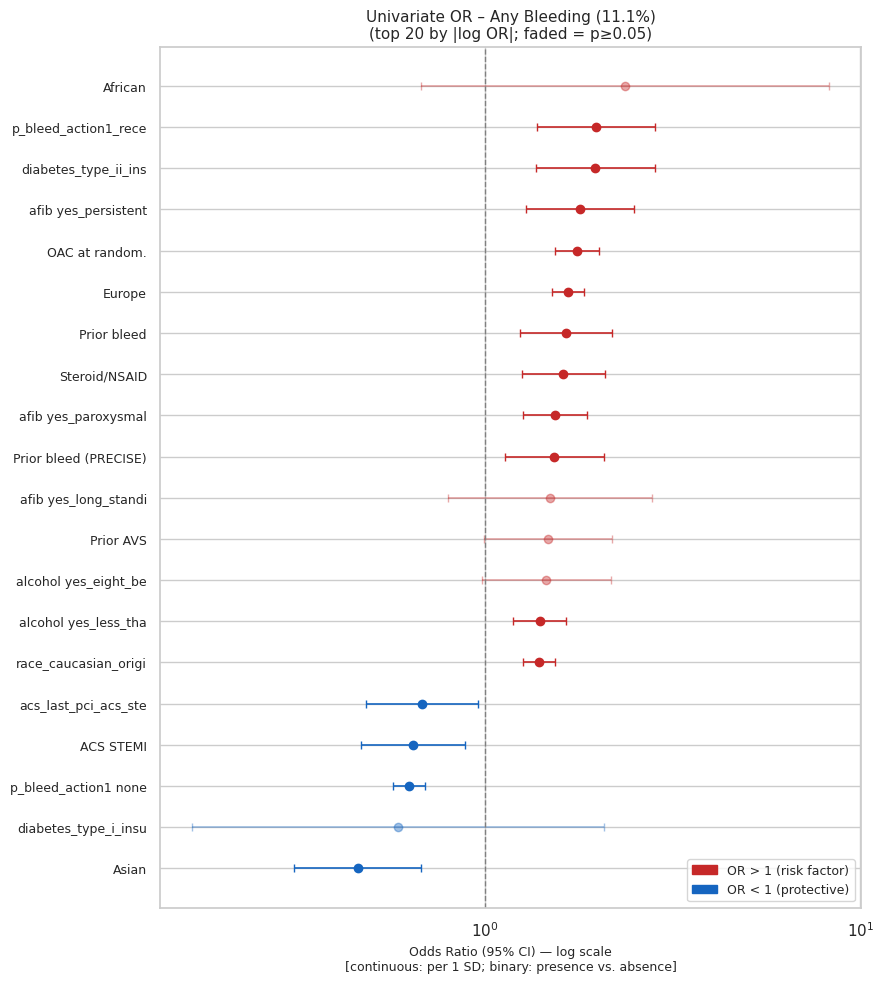

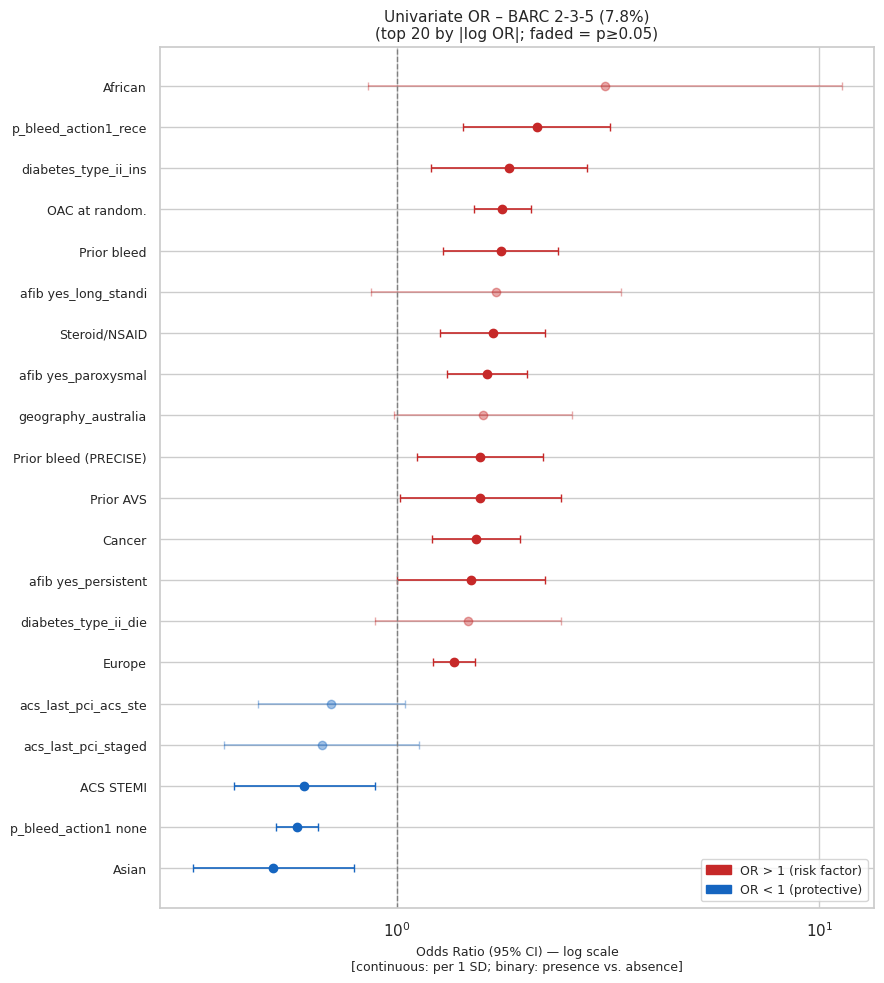

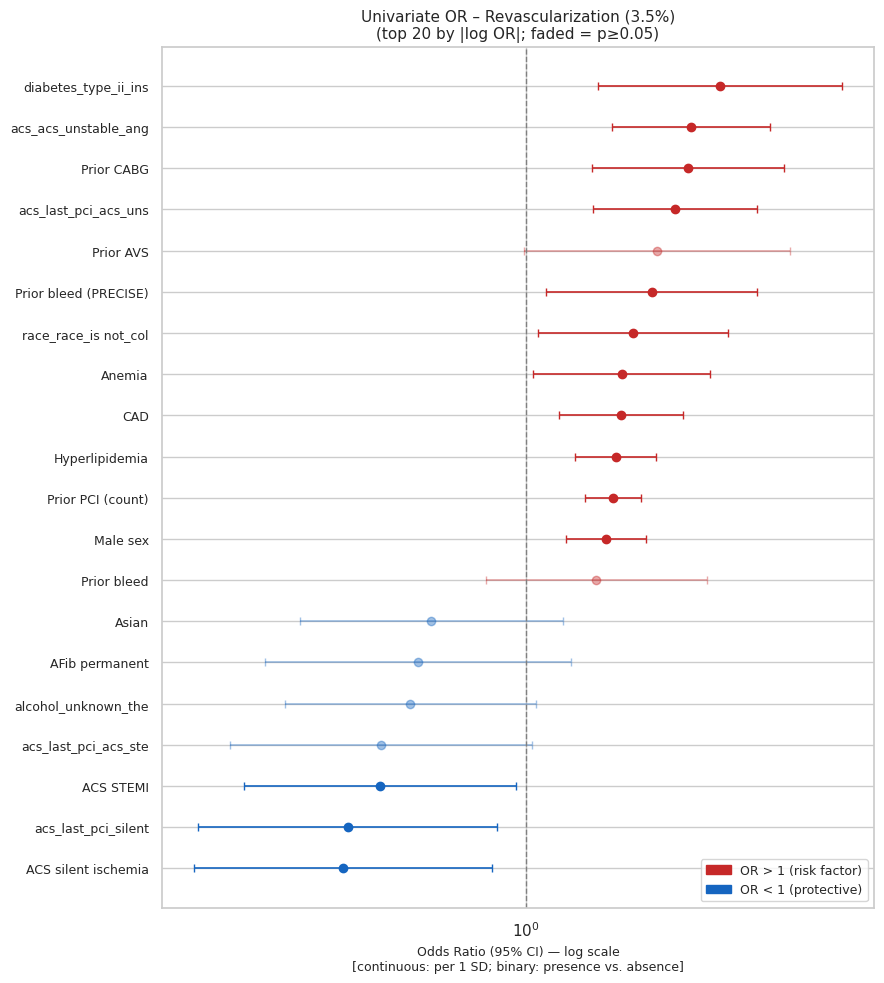

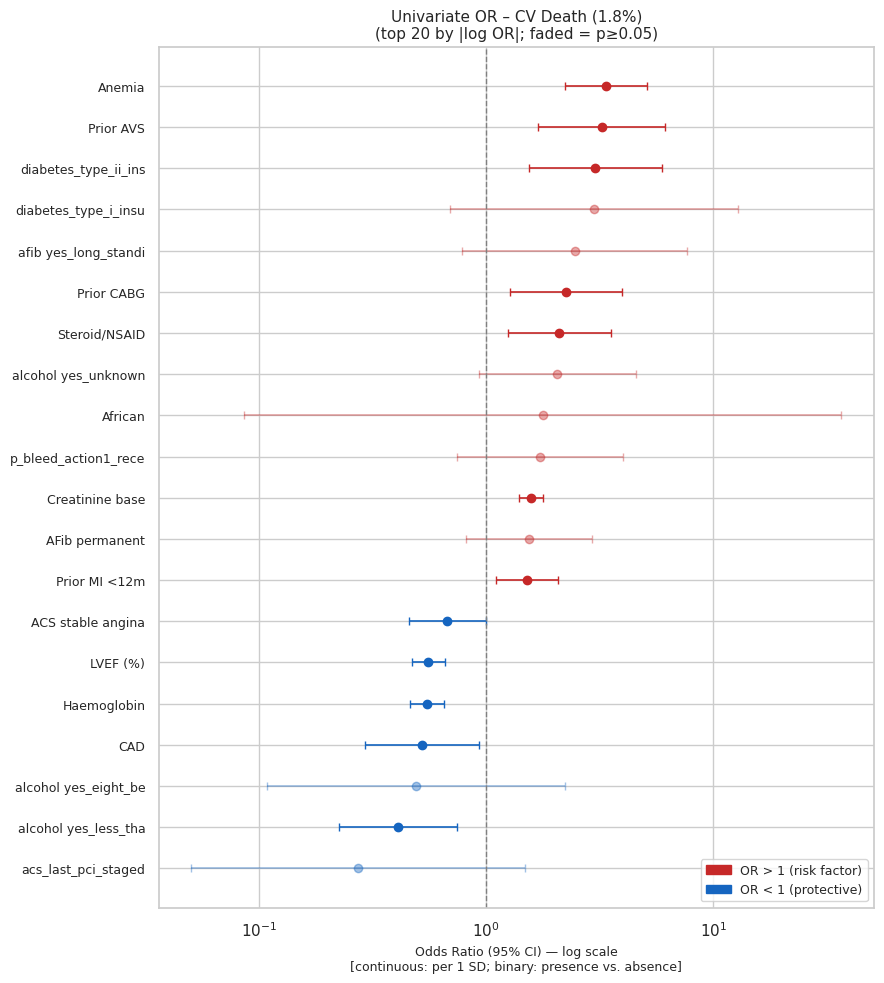

In [7]:
TOP_N = 20

for target_col, target_lbl in FOCUS_TARGETS.items():
    sub = (
        or_df[or_df['target'] == target_col]
        .dropna(subset=['or', 'ci_lo', 'ci_hi'])
        .assign(abs_log_or=lambda d: d['log_or'].abs())
        .sort_values('abs_log_or', ascending=False)
        .head(TOP_N)
        .sort_values('log_or')
    )
    sub = sub.assign(label=sub['feature'].map(shorten))

    fig, ax = plt.subplots(figsize=(9, max(5, len(sub) * 0.5)))

    for _, row in sub.iterrows():
        sig = row['p_value'] < 0.05 if not np.isnan(row['p_value']) else False
        color = '#C62828' if row['log_or'] > 0 else '#1565C0'
        alpha = 1.0 if sig else 0.4
        ax.errorbar(
            x=row['or'], y=row['label'],
            xerr=[[row['or'] - row['ci_lo']], [row['ci_hi'] - row['or']]],
            fmt='o', color=color, alpha=alpha,
            markersize=6, capsize=3, elinewidth=1.2
        )

    ax.axvline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel('Odds Ratio (95% CI) — log scale\n[continuous: per 1 SD; binary: presence vs. absence]',
                  fontsize=9)
    ax.set_title(
        f'Univariate OR – {target_lbl}\n'
        f'(top {len(sub)} by |log OR|; faded = p≥0.05)',
        fontsize=11
    )
    ax.tick_params(axis='y', labelsize=9)

    red_patch  = mpatches.Patch(color='#C62828', label='OR > 1 (risk factor)')
    blue_patch = mpatches.Patch(color='#1565C0', label='OR < 1 (protective)')
    ax.legend(handles=[red_patch, blue_patch], fontsize=9, loc='lower right')

    plt.tight_layout()
    plt.show()

In [8]:
# Summary table: top 10 features per target, significant only
print('Significant univariate associations (p < 0.05) – top 10 per target by |log OR|')
print('=' * 80)
for target_col, target_lbl in TARGET_LABELS.items():
    sub = (
        or_df[(or_df['target'] == target_col) & (or_df['p_value'] < 0.05)]
        .dropna(subset=['or'])
        .assign(abs_log_or=lambda d: d['log_or'].abs())
        .sort_values('abs_log_or', ascending=False)
        .head(10)
        .assign(feature=lambda d: d['feature'].map(shorten))
        [['feature', 'or', 'ci_lo', 'ci_hi', 'p_value']]
        .reset_index(drop=True)
    )
    if not sub.empty:
        print(f'\n{target_lbl}:')
        display(sub.style.format({'or': '{:.2f}', 'ci_lo': '{:.2f}', 'ci_hi': '{:.2f}', 'p_value': '{:.4f}'}))

Significant univariate associations (p < 0.05) – top 10 per target by |log OR|

Any Bleeding:


,feature,or,ci_lo,ci_hi,p_value
0,Asian,0.46,0.31,0.67,0.0001
1,p_bleed_action1_rece,1.97,1.37,2.83,0.0002
2,diabetes_type_ii_ins,1.97,1.36,2.84,0.0003
3,afib yes_persistent,1.79,1.28,2.49,0.0006
4,OAC at random.,1.76,1.53,2.01,0.0000
5,Europe,1.67,1.51,1.84,0.0000
6,Prior bleed,1.64,1.24,2.17,0.0005
7,Steroid/NSAID,1.61,1.25,2.08,0.0002
8,p_bleed_action1 none,0.63,0.57,0.69,0.0000
9,ACS STEMI,0.64,0.47,0.88,0.0062



BARC 2-3-5:


,feature,or,ci_lo,ci_hi,p_value
0,p_bleed_action1_rece,2.14,1.44,3.19,0.0002
1,Asian,0.51,0.33,0.79,0.0027
2,diabetes_type_ii_ins,1.84,1.20,2.82,0.0049
3,OAC at random.,1.77,1.52,2.07,0.0000
4,Prior bleed,1.76,1.28,2.41,0.0004
5,p_bleed_action1 none,0.58,0.52,0.65,0.0000
6,Steroid/NSAID,1.68,1.26,2.25,0.0004
7,ACS STEMI,0.60,0.41,0.88,0.0097
8,afib yes_paroxysmal,1.63,1.31,2.03,0.0000
9,Prior bleed (PRECISE),1.57,1.12,2.22,0.0099



Revascularization:


...

,feature,or,ci_lo,ci_hi,p_value
0,Asian,0.48,0.28,0.82,0.0077
1,p_bleed_action1_rece,1.89,1.16,3.05,0.0098
2,diabetes_type_ii_ins,1.82,1.11,2.99,0.0171
3,OAC at random.,1.73,1.44,2.08,0.0000
4,Cancer,1.72,1.32,2.25,0.0001
5,Prior bleed,1.66,1.15,2.41,0.0074
6,ACS STEMI,0.61,0.39,0.96,0.0321
7,Prior bleed (PRECISE),1.63,1.10,2.42,0.0155
8,p_bleed_action1 none,0.62,0.54,0.71,0.0000
9,afib yes_paroxysmal,1.51,1.16,1.97,0.0020



BARC 3:


,feature,or,ci_lo,ci_hi,p_value
0,Steroid/NSAID,2.78,1.86,4.17,0.0000
1,diabetes_type_ii_in1,2.49,1.39,4.44,0.0021
2,Anemia,2.22,1.47,3.34,0.0001
3,OAC at random.,1.90,1.46,2.47,0.0000
4,afib yes_paroxysmal,1.87,1.31,2.67,0.0006
5,Haemoglobin,0.58,0.50,0.68,0.0000
6,alcohol_unknown_the,1.64,1.06,2.55,0.0277
7,p_bleed_action1 none,0.63,0.52,0.77,0.0000
8,Platelets pre,1.41,1.19,1.67,0.0001
9,Age (months),1.37,1.11,1.69,0.0032



BARC 3-5:


,feature,or,ci_lo,ci_hi,p_value
0,Steroid/NSAID,2.90,1.98,4.25,0.0000
1,Anemia,2.43,1.66,3.55,0.0000
2,p_bleed_action1_rece,2.40,1.31,4.40,0.0047
3,diabetes_type_ii_in1,2.37,1.34,4.19,0.0030
4,Prior AVS,1.93,1.00,3.71,0.0497
5,afib yes_paroxysmal,1.84,1.31,2.60,0.0005
6,OAC at random.,1.83,1.42,2.36,0.0000
7,p_bleed_action1 none,0.56,0.46,0.68,0.0000
8,Prior bleed,1.74,1.04,2.89,0.0339
9,Haemoglobin,0.58,0.50,0.68,0.0000


## 5. Mutual Information between Features and Targets

Mutual information (MI) quantifies the non-linear statistical dependency between each
feature and a binary target. Unlike correlation or OR, it captures any type of
relationship (not just monotone or linear). MI is computed with 5 nearest neighbours
(sklearn default) and averaged over 3 random seeds for stability.

Values are not directly comparable across targets (different base rates produce
different upper bounds), so we rank within each target.

In [9]:
X_mi = X_full.copy()

mi_results = {}
for target_col in TARGET_LABELS:
    t = y[target_col].astype(int).values
    # Average over 3 seeds for stability
    mi_runs = np.vstack([
        mutual_info_classif(X_mi, t, discrete_features='auto', random_state=s)
        for s in [0, 1, 2]
    ])
    mi_results[target_col] = mi_runs.mean(axis=0)

mi_df = pd.DataFrame(mi_results, index=X_mi.columns)
mi_df.columns = [TARGET_LABELS[c] for c in mi_df.columns]

print('Mutual information computed for all features × targets.')
print(f'Shape: {mi_df.shape}')

Mutual information computed for all features × targets.
Shape: (60, 9)


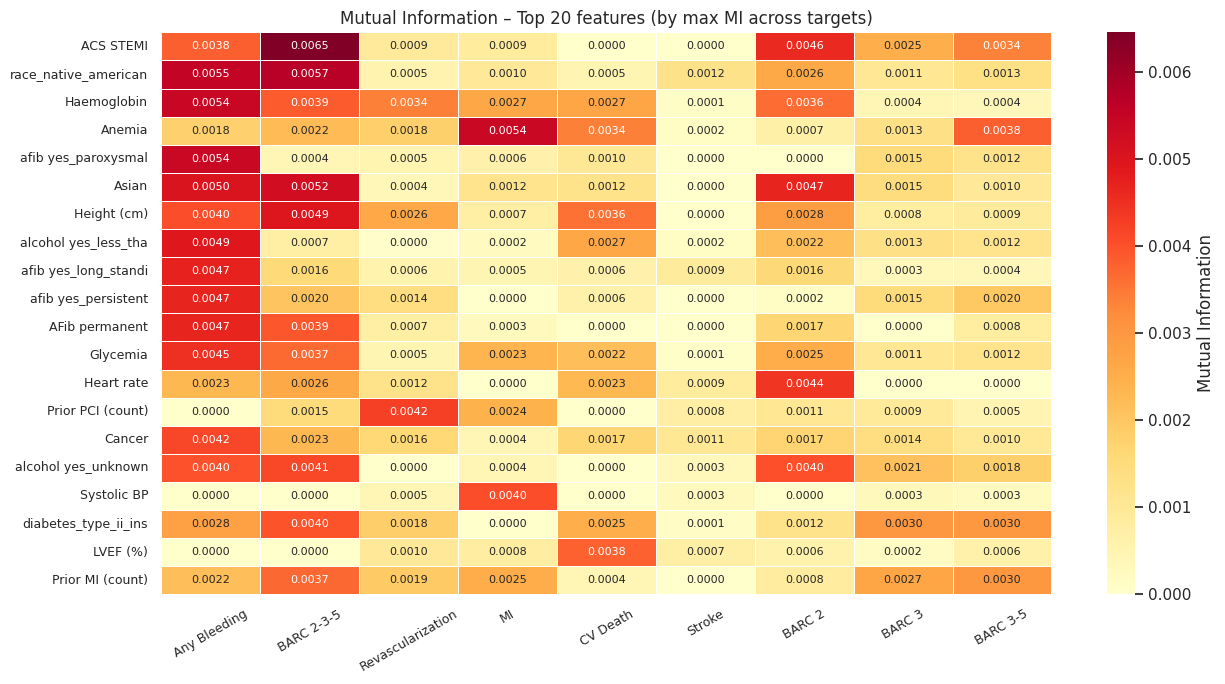

In [10]:
TOP_MI = 20

# Heatmap: top features across all targets — rename index with shorten()
top_features_mi = mi_df.max(axis=1).nlargest(TOP_MI).index
mi_top = mi_df.loc[top_features_mi].rename(index=shorten)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    mi_top, annot=True, fmt='.4f', cmap='YlOrRd',
    ax=ax, linewidths=0.4, annot_kws={'size': 8},
    cbar_kws={'label': 'Mutual Information'}
)
ax.set_title(f'Mutual Information – Top {TOP_MI} features (by max MI across targets)', fontsize=12)
ax.tick_params(axis='x', labelrotation=30, labelsize=9)
ax.tick_params(axis='y', labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()

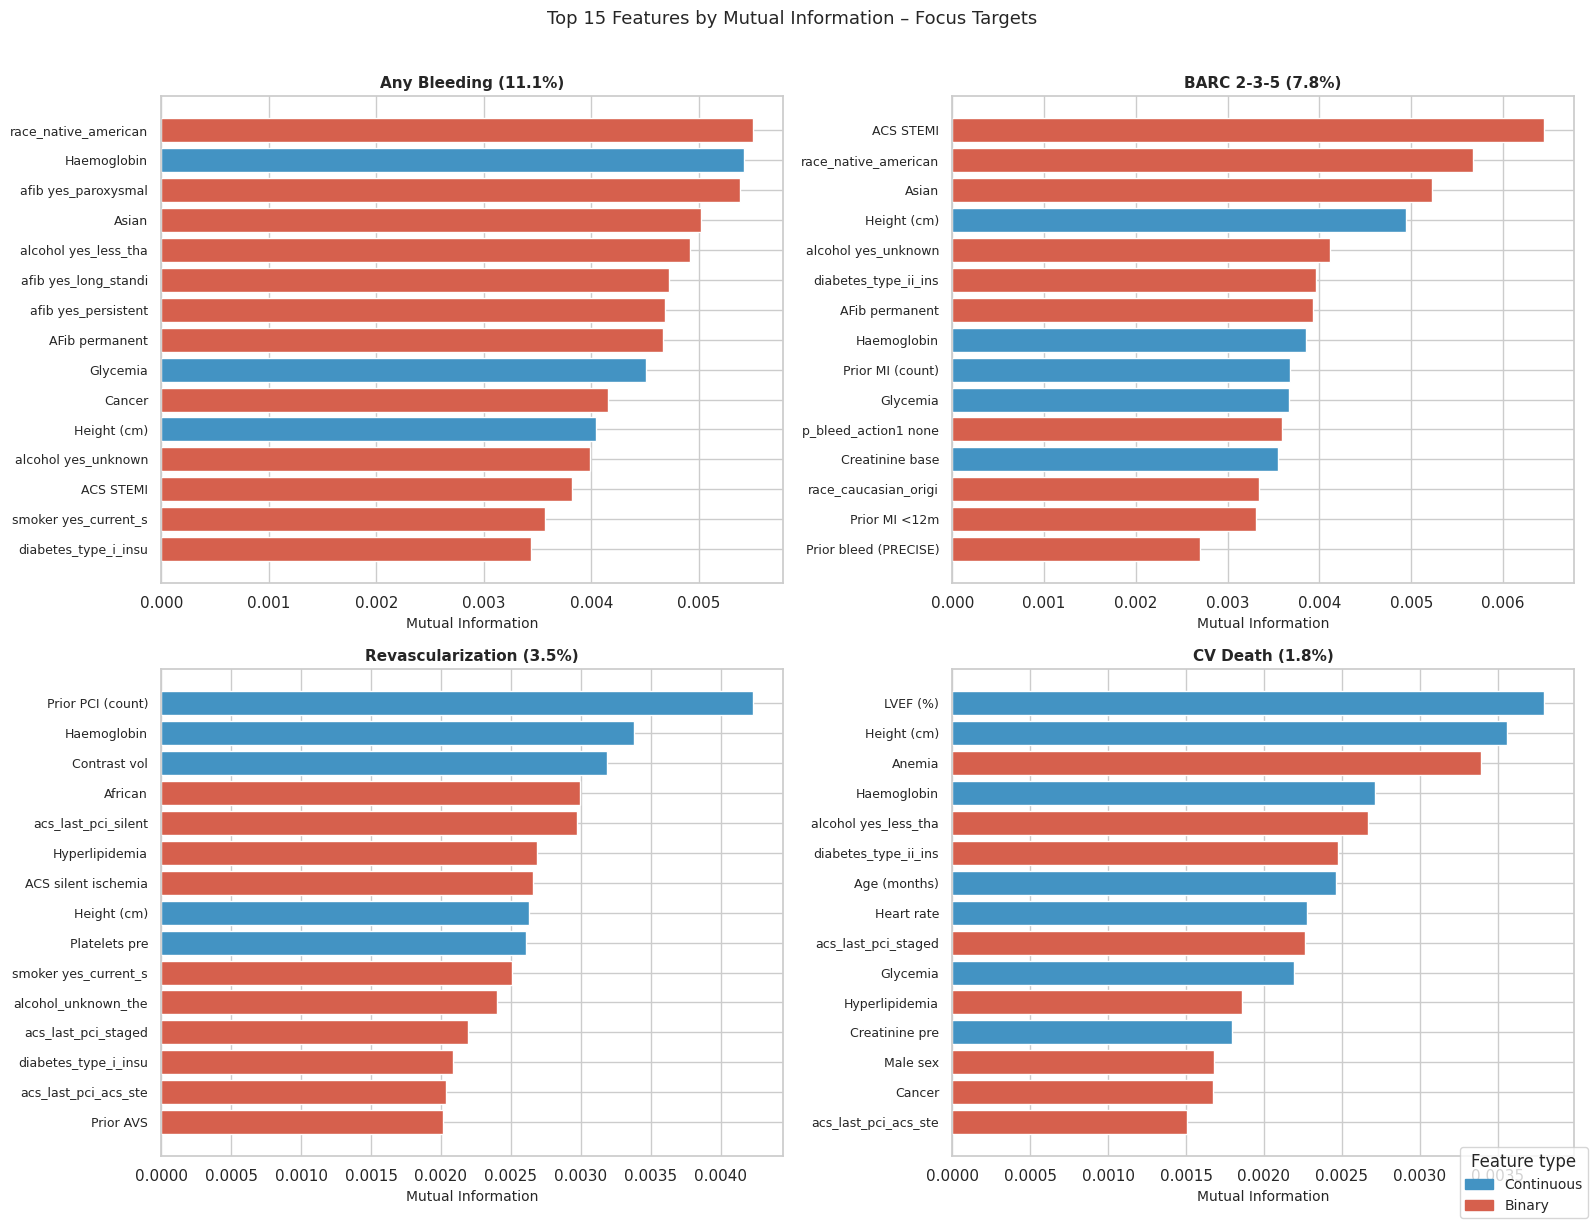

In [11]:
# Bar charts: top 15 features per focus target
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (target_col, target_lbl) in enumerate(FOCUS_TARGETS.items()):
    ax = axes[i]
    col_name = TARGET_LABELS[target_col]
    top = mi_df[col_name].nlargest(15).sort_values()
    short_labels = [shorten(f) for f in top.index]

    colors = ['#4393c3' if f in CONTINUOUS_FEATURES else '#d6604d' for f in top.index]
    ax.barh(short_labels, top.values, color=colors)
    ax.set_xlabel('Mutual Information', fontsize=10)
    ax.set_title(f'{target_lbl}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

cont_patch = mpatches.Patch(color='#4393c3', label='Continuous')
bin_patch  = mpatches.Patch(color='#d6604d', label='Binary')
fig.legend(handles=[cont_patch, bin_patch], loc='lower right', title='Feature type', fontsize=10)
fig.suptitle('Top 15 Features by Mutual Information – Focus Targets', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Binary Feature Co-occurrence (Cramér's V among Predictors)

While sections 2–5 relate features to targets, this section looks at the *inter-feature*
structure of the 48 binary predictors. Knowing which comorbidities or clinical flags
cluster together is useful before modelling: highly co-occurring features carry
redundant information and may inflate coefficient estimates.

We compute Cramér's V (a symmetric measure of association for categorical variables,
ranging from 0 to 1) for every pair of binary features.

In [12]:
def cramers_v(x, y_):
    ct = pd.crosstab(x, y_)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    phi2_corr = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

# Compute Cramér's V matrix for binary features
B = X[BINARY_FEATURES].astype(int)
n_bin = len(BINARY_FEATURES)
V_matrix = np.eye(n_bin)

for i, a in enumerate(BINARY_FEATURES):
    for j, b in enumerate(BINARY_FEATURES):
        if i < j:
            v = cramers_v(B[a], B[b])
            V_matrix[i, j] = v
            V_matrix[j, i] = v

# Build DataFrame with short labels on both axes
short_bin_labels = [shorten(f) for f in BINARY_FEATURES]
V_df = pd.DataFrame(V_matrix, index=short_bin_labels, columns=short_bin_labels)

# Identify strongly associated pairs (V > 0.3) — keep original names for reference
pairs = []
for i, a in enumerate(BINARY_FEATURES):
    for j, b in enumerate(BINARY_FEATURES):
        if i < j and V_matrix[i, j] > 0.3:
            pairs.append({
                'feature_1': shorten(a), 'feature_2': shorten(b),
                'cramers_v': round(V_matrix[i, j], 3)
            })

pairs_df = pd.DataFrame(pairs).sort_values('cramers_v', ascending=False)
print(f"Binary feature pairs with Cramér's V > 0.3: {len(pairs_df)}")
display(pairs_df.head(20))

Binary feature pairs with Cramér's V > 0.3: 21


,feature_1,feature_2,cramers_v
6,Prior bleed,p_bleed_action1 none,0.991
16,acs_last_pci_acs_uns,acs_acs_unstable_ang,0.956
18,acs_last_pci_stable,ACS stable angina,0.940
17,acs_last_pci_silent,ACS silent ischemia,0.934
15,acs_last_pci_acs_ste,ACS STEMI,0.892
2,Prior bleed (PRECISE),Prior bleed,0.871
4,Prior bleed (PRECISE),p_bleed_action1 none,0.865
12,Europe,Asian,0.749
14,p_bleed_action1_rece,p_bleed_action1 none,0.717
5,Prior bleed,p_bleed_action1_rece,0.711


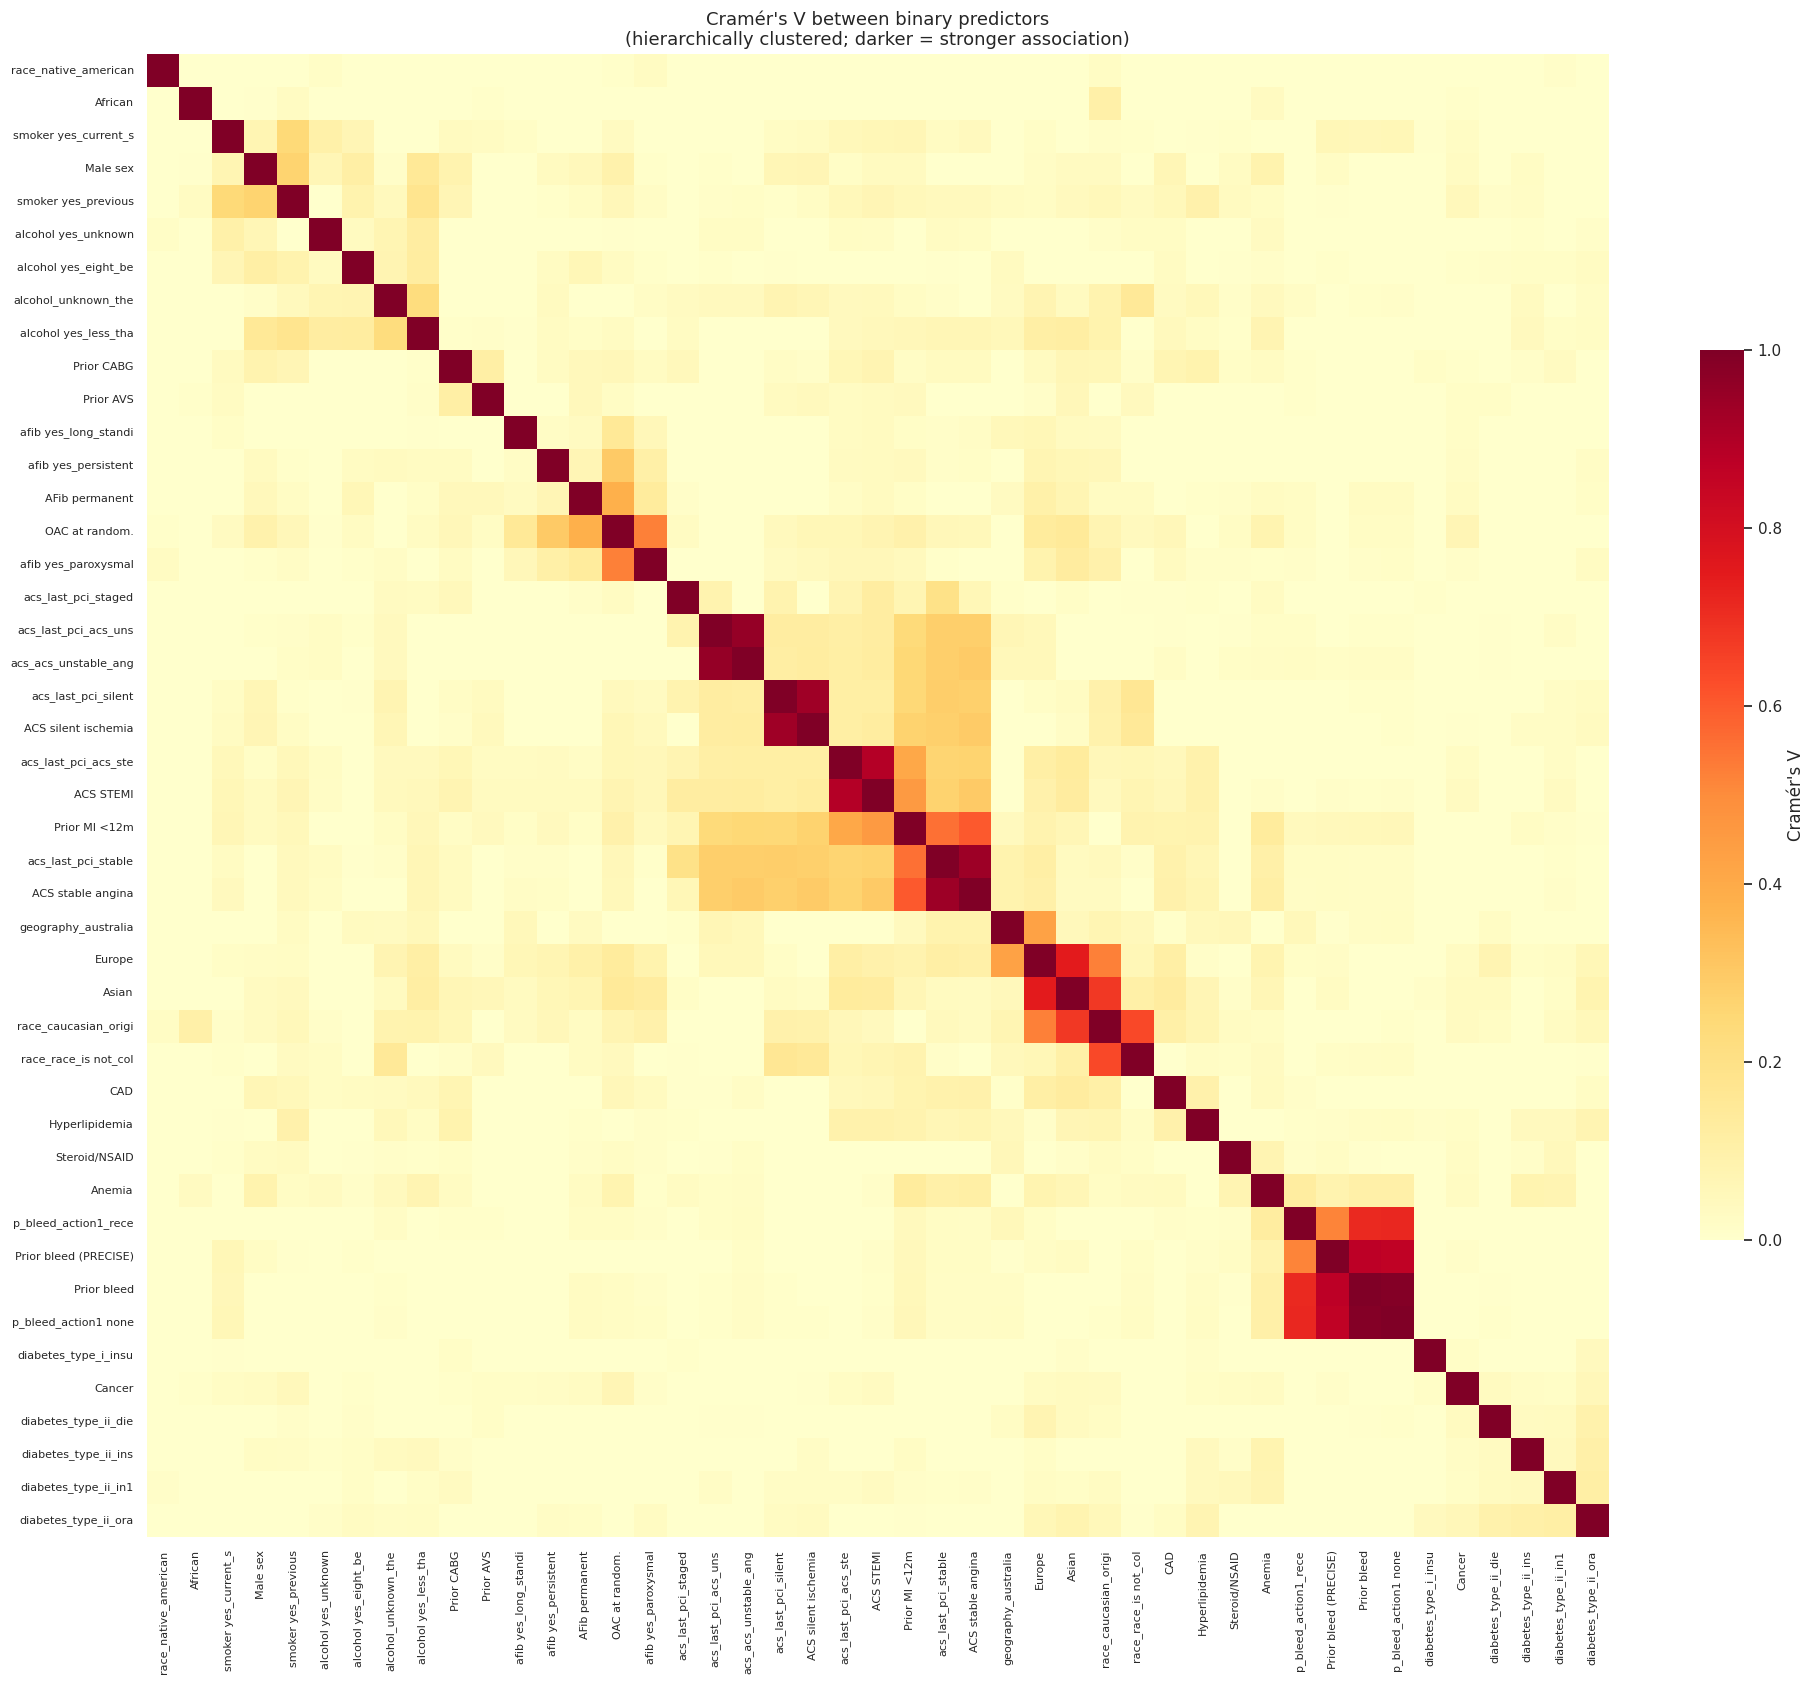

In [13]:
# Heatmap – cluster binary features by Cramér's V (short labels already on V_df)
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

dist_matrix = 1 - V_df.values
np.fill_diagonal(dist_matrix, 0)
condensed = squareform(dist_matrix, checks=False)
Z = linkage(condensed, method='average')
order = leaves_list(Z)

V_ordered = V_df.iloc[order, order]

fig, ax = plt.subplots(figsize=(20, 17))
sns.heatmap(
    V_ordered, ax=ax,
    cmap='YlOrRd', vmin=0, vmax=1,
    xticklabels=True, yticklabels=True,
    linewidths=0, cbar_kws={'label': "Cramér's V", 'shrink': 0.6}
)
ax.set_title(
    "Cramér's V between binary predictors\n"
    "(hierarchically clustered; darker = stronger association)",
    fontsize=13
)
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.tick_params(axis='y', labelrotation=0, labelsize=8)
plt.tight_layout()
plt.show()

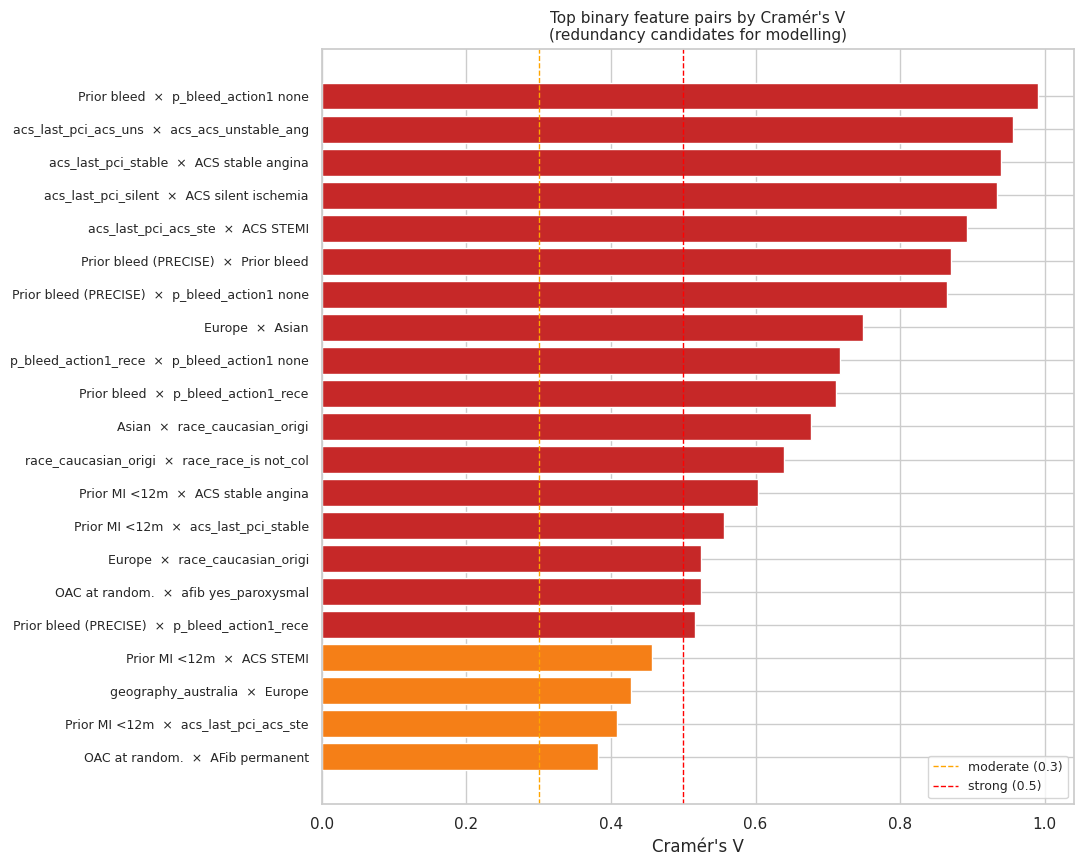

In [14]:
# Bar chart: top 25 binary feature pairs by Cramér's V (labels already shortened)
if not pairs_df.empty:
    top_pairs = pairs_df.head(25).sort_values('cramers_v')
    pair_labels = (top_pairs['feature_1'] + '  ×  ' + top_pairs['feature_2']).tolist()
    colors = ['#C62828' if v > 0.5 else '#F57F17' for v in top_pairs['cramers_v']]

    fig, ax = plt.subplots(figsize=(11, max(5, len(top_pairs) * 0.42)))
    ax.barh(pair_labels, top_pairs['cramers_v'].values, color=colors)
    ax.axvline(0.3, color='orange', linestyle='--', linewidth=1, label='moderate (0.3)')
    ax.axvline(0.5, color='red',    linestyle='--', linewidth=1, label='strong (0.5)')
    ax.set_xlabel("Cramér's V")
    ax.set_title("Top binary feature pairs by Cramér's V\n(redundancy candidates for modelling)",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No binary feature pairs with Cramér's V > 0.3 found.")

## Summary

**Continuous features by outcome (Section 2)**
- Haemoglobin (`prec_hb`), creatinine, and platelet-related markers show the strongest
  distributional shifts between bleeders and non-bleeders, consistent with the
  PRECISE-DAPT score components.
- For ischemic endpoints (MI, CV death, revascularization), troponin and LVEF
  differences are more pronounced.

**Binary features by outcome (Section 3)**
- Baseline bleeding risk flags (`prec_priorbleed`, `p_bleed`) are enriched in
  bleeding event patients; prior MI and CAD in ischemic patients.

**Univariate odds ratios (Section 4)**
- The forest plot highlights which features are both large-effect and significant;
  it also reveals protective predictors (OR < 1) such as high haemoglobin for bleeding.
- Results should be interpreted as crude associations — no adjustment for confounders.

**Mutual information (Section 5)**
- MI rankings broadly agree with point-biserial / Cramér's V rankings from
  `01_target_exploration`, but surface additional non-linear associations not captured
  by linear measures.

**Binary feature co-occurrence (Section 6)**
- Strongly co-occurring binary predictor pairs are candidates for redundancy reduction
  (e.g. `acs` and `acs_last_pci` dummies, bleeding-history flags). Consider removing
  one from each highly associated pair before training tree-based or regularised models.